<a href="https://colab.research.google.com/github/mkrajevsky/NLP_guzman/blob/main/Final_prpject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**This project is about creating, training and evaluating LSTM model for sentiment analysis.**

The used dataset is from HuggingFace https://huggingface.co/datasets/dair-ai/emotion. The task is multiclass classicication with 6 classes.

Downloading not provided packages

In [ ]:
!pip install ipywidgets==7.7.1
!pip install --upgrade huggingface_hub
!pip install datasets
!pip install transformers
!pip install pipreqsnb


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 14.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 16.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 9.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 22.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 17.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.31.0
    Uninstalling requests-2.31.0:
      Successfully uninstalled requests-2.31.0
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 14.0.2
    Uninstalling pyarrow-14.0.2:
      Successfully uninstalled pyarrow-14.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed.

In [ ]:
!huggingface-cli login


    _|    _|  _|    _|    _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|_|_|_|    _|_|      _|_|_|  _|_|_|_|
    _|    _|  _|    _|  _|        _|          _|    _|_|    _|  _|            _|        _|    _|  _|        _|
    _|_|_|_|  _|    _|  _|  _|_|  _|  _|_|    _|    _|  _|  _|  _|  _|_|      _|_|_|    _|_|_|_|  _|        _|_|_|
    _|    _|  _|    _|  _|    _|  _|    _|    _|    _|    _|_|  _|    _|      _|        _|    _|  _|        _|
    _|    _|    _|_|      _|_|_|    _|_|_|  _|_|_|  _|      _|    _|_|_|      _|        _|    _|    _|_|_|  _|_|_|_|

    To login, `huggingface_hub` requires a token generated from https://huggingface.co/settings/tokens .
Enter your token (input will not be visible): 
Add token as git credential? (Y/n) n
Token is valid (permission: read).
Your token has been saved to /root/.cache/huggingface/token
Login successful


In [ ]:
import huggingface_hub
import numpy as np
import pandas as pd
from datasets import load_dataset
from datasets import concatenate_datasets

In [ ]:
def load_data(shuffle = False, split_r = 0.1):

  ds = load_dataset("dair-ai/emotion","split")
  print(ds)

  train = ds["train"]
  test = ds["test"]
  val = ds["validation"]

  if shuffle:
    ds = ds.shuffle(seed=42)
    train = ds["train"].select(range(int(16000*(1-split_r)+1600)))
    test = concatenate_datasets([ds["train"].select(range(int(split_r*16000)-1600)), ds["test"]])
    val = ds["validation"]

  print(train)
  print(test)
  print(val)

  return train, test, val


train,test,val = load_data(shuffle=True, split_r = 0.1)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})


In [ ]:
emotions = ["sadness" , "joy", "love", "anger" , "fear", "surprise"]

encoded_labels = {i:emotions[i] for i in range(6)}

In [ ]:

def summarize_data(train_data,test_data):
  df = pd.DataFrame(columns = ["Label","Total Data", "Training Data", "Test Data"] )
  for i in range(len(emotions)):
    row = {"Label": None,"Total Data": 0, "Training Data": 0, "Test Data": 0}
    row["Label"] = encoded_labels[i]

    row["Training Data"] = train_data["label"].count(i)
    row["Test Data"] = test_data["label"].count(i)
    row["Total Data"] = row["Training Data"] + row["Test Data"]
    df = df._append(row,ignore_index=True)
  return df

summarize_data( test_data=test, train_data=train)

,Label,Total Data,Training Data,Test Data
0,sadness,5247,4666,581
1,joy,6057,5362,695
2,love,1463,1304,159
3,anger,2434,2159,275
4,fear,2161,1937,224
5,surprise,638,572,66


In [ ]:
import nltk
from keras.utils import to_categorical
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Bidirectional, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:


stemmer = PorterStemmer()
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Function to preprocess data with stemming and stopword removal
def preprocess_text(text):
    tokens = [stemmer.stem(word) for word in text.split() if word not in stop_words]
    return " ".join(tokens)

def preprocess(train,val,test):

  train = train.map(lambda example: {'clean': preprocess_text(example['text'])})

  # For val dataset
  val = val.map(lambda example: {'clean': preprocess_text(example['text'])})

  # For test dataset
  test = test.map(lambda example: {'clean': preprocess_text(example['text'])})
  return train,val,test

train,val,test = preprocess(train,val,test)
# Create a tokenizer with combined training, validation, and test data
def get_tokenizer(train,val,test):
  all_texts = train['clean'] + test['clean'] + val['clean']
  tokenizer = Tokenizer(num_words=16000)
  tokenizer.fit_on_texts(all_texts)
  word_index = tokenizer.word_index

  return tokenizer

tokenizer = get_tokenizer(train,val,test)

# Function to preprocess data with stemming and tokenization
def preprocess_data(data):
    processed_data = []
    for row in data: # Iterate directly over Dataset object
        sequence = tokenizer.texts_to_sequences([row['clean'].split()])[0]
        processed_data.append([sequence, row['label']])
    return processed_data

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
# Preprocess training and validation datasets
def preprocess_data_(train,val,test):
  train_data_processed = preprocess_data(train)
  val_data_processed = preprocess_data(val)

  # Separate features and labels, and pad sequences
  max_seq_length = max(len(seq[0]) for seq in train_data_processed)
  train_X = pad_sequences([row[0] for row in train_data_processed], maxlen=max_seq_length, padding='post')
  train_y = np.array([row[1] for row in train_data_processed])

  val_X = pad_sequences([row[0] for row in val_data_processed], maxlen=max_seq_length, padding='post')
  val_y = np.array([row[1] for row in val_data_processed])

  # Convert labels to one-hot encoding
  num_classes = len(emotions)
  train_y_one_hot = to_categorical(train_y, num_classes=num_classes)
  val_y_one_hot = to_categorical(val_y, num_classes=num_classes)

  print(f"Training set shape: {train_X.shape}, {train_y.shape}")
  print(f"Validation set shape: {val_X.shape}, {val_y.shape}")

  return train_X, train_y_one_hot, val_X, val_y_one_hot, max_seq_length

train_X, train_y_one_hot, val_X, val_y_one_hot, max_seq_length = preprocess_data_(train,val,test)

# Build an optimized bidirectional LSTM model
class LSTMModel():
  def __init__(self, num_classes, max_seq_length):
    self.model = Sequential([
        Embedding(input_dim=16000, output_dim=100, input_length=max_seq_length),
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.3),
        LSTM(64),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])

    # Compile the model
    optimizer = Adam(learning_rate=0.003)
    self.model.compile(loss='categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])


  def fit(self, train_X, train_y_one_hot, val_X,val_y_one_hot, n_epochs):
    # Train the model
    history = self.model.fit(train_X, train_y_one_hot, epochs=n_epochs, validation_data=(val_X, val_y_one_hot), verbose=1)
    return history


  def predict(self, test_X):
    # Predict classes
    y_pred = self.model.predict(test_X)
    y_pred = self.model.predict(test_X)
    y_pred_classes = np.argmax(y_pred, axis=1)
    return np.argmax(y_pred, axis=1)

#model = LSTMModel(6, max_seq_length)
#history = model.fit(train_X, train_y_one_hot, val_X,val_y_one_hot,5)

Training set shape: (16000, 35), (16000,)
Validation set shape: (2000, 35), (2000,)


In [ ]:
from matplotlib import pyplot as plt
import random

In [ ]:

#Function to plot accuracy
def plot_history_acc(history):

  plt.plot(history.history['accuracy'], label='Train Accuracy')
  plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
  plt.title('Training vs Validation Accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

#plot_history_acc(history)

# Function to plot loss
def plot_history_loss(history):
  plt.plot(history.history['loss'], label='Train Loss')
  plt.plot(history.history['val_loss'], label='Validation Loss')
  plt.title('Training vs Validation Loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

#plot_history_loss(history)


# Evaluate on entire test set
def preprocess_test_data(test):
  test_data_processed = preprocess_data(test)
  test_X = pad_sequences([row[0] for row in test_data_processed], maxlen=max_seq_length, padding='post')
  test_y = np.array([row[1] for row in test_data_processed])

  test_y_one_hot = to_categorical(test_y, num_classes=6)
  return test_X, test_y_one_hot, test_y

#test_X, test_y_one_hot, test_y = preprocess_test_data(test)
#y_pred_classes = model.predict(test_X)



In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [ ]:
def plot_confusion_matrix(test_y, y_pred_classes):
  cm = confusion_matrix(test_y, y_pred_classes)
  df_cm = pd.DataFrame(cm, index=encoded_labels.values(), columns=encoded_labels.values())
  ax = sns.heatmap(df_cm, annot=True, fmt='d', square=True, cbar=False, cmap='Blues')
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()

#plot_confusion_matrix(test_y, y_pred_classes)

In [ ]:
def summarize(mini_ds, train_data, test_data, y_pred_classes):
  df = pd.DataFrame(columns = ["Label","Total Data", "Training Data", "Test Data", "Correct predictions", "Accuracy"] )
  total = {"Label": "Total","Total Data": 0, "Training Data": 0, "Test Data": 0, "Correct predictions": 0, "Accuracy": 0}
  for i in range(len(emotions)):

    encoded_label = encoded_labels[i]
    row = {"Label": None,"Total Data": None, "Training Data": None, "Test Data": None, "Correct predictions": None, "Accuracy":None}
    row["Label"] = encoded_label
    row["Total Data"] = mini_ds["label"].count(i)
    row["Training Data"] = train_data["label"].count(i)
    row["Test Data"] = test_data["label"].count(i)
    row["Correct predictions"] = sum(1 for pred, label in zip(y_pred_classes, test_data["label"]) if pred == label and label == i)
    row["Accuracy"] = row["Correct predictions"] / row["Test Data"]
    total["Total Data"] += row["Total Data"]
    total["Training Data"] += row["Training Data"]
    total["Test Data"] += row["Test Data"]
    total["Correct predictions"] += row["Correct predictions"]
    df = df._append(row, ignore_index=True)

  total["Accuracy"] = total["Correct predictions"] / total["Test Data"]
  df = df._append(total, ignore_index=True)

  return df

#summarize(concatenate_datasets([train,test]),train,test,y_pred_classes)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Dataset({
    features: ['text', 'label'],
    num_rows: 15200
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2800
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})


Map:   0%|          | 0/15200 [00:00<?, ? examples/s]

Map:   0%|          | 0/2800 [00:00<?, ? examples/s]

Training set shape: (15200, 35), (15200,)
Validation set shape: (2800, 35), (2800,)
Epoch 1/10
475/475 [==============================] - 85s 168ms/step - loss: 1.5756 - accuracy: 0.3239 - val_loss: 1.5076 - val_accuracy: 0.3107
Epoch 2/10
475/475 [==============================] - 79s 166ms/step - loss: 1.4050 - accuracy: 0.3743 - val_loss: 1.2407 - val_accuracy: 0.4350
Epoch 3/10
475/475 [==============================] - 74s 156ms/step - loss: 1.2152 - accuracy: 0.4373 - val_loss: 1.2219 - val_accuracy: 0.4229
Epoch 4/10
475/475 [==============================] - 78s 165ms/step - loss: 1.3023 - accuracy: 0.4436 - val_loss: 1.0647 - val_accuracy: 0.5636
Epoch 5/10
475/475 [==============================] - 75s 158ms/step - loss: 0.8659 - accuracy: 0.6605 - val_loss: 0.8160 - val_accuracy: 0.6857
Epoch 6/10
475/475 [==============================] - 76s 159ms/step - loss: 0.6803 - accuracy: 0.7319 - val_loss: 0.6440 - val_accuracy: 0.7518
Epoch 7/10
475/475 [==========================

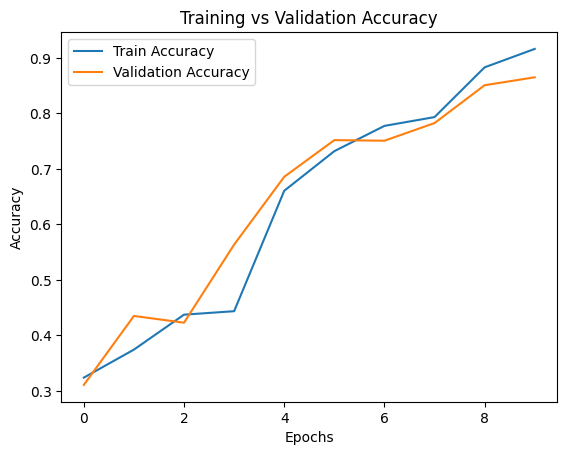

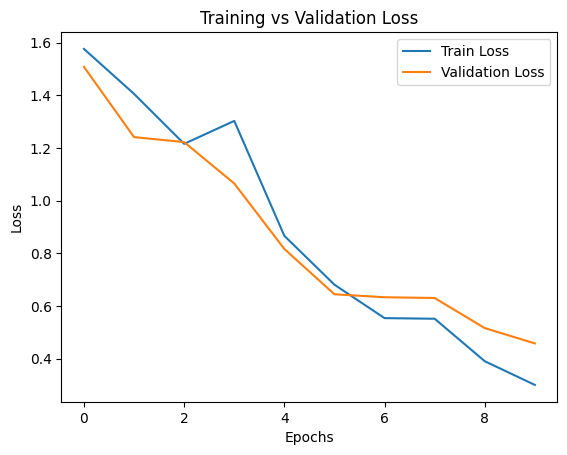

63/63 [==============================] - 2s 39ms/step


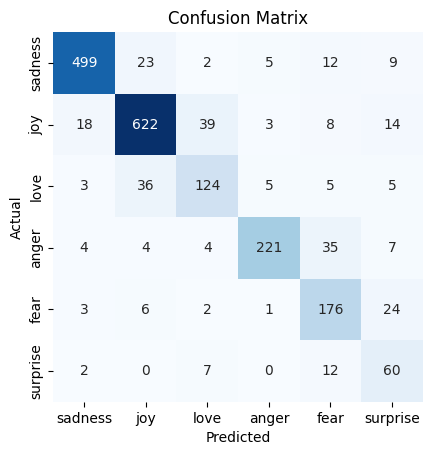

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Dataset({
    features: ['text', 'label'],
    num_rows: 14400
})
Dataset({
    features: ['text', 'label'],
    num_rows: 3600
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})


Map:   0%|          | 0/14400 [00:00<?, ? examples/s]

Map:   0%|          | 0/3600 [00:00<?, ? examples/s]

Training set shape: (14400, 35), (14400,)
Validation set shape: (3600, 35), (3600,)
Epoch 1/15
450/450 [==============================] - 86s 180ms/step - loss: 1.5939 - accuracy: 0.3241 - val_loss: 1.5748 - val_accuracy: 0.2892
Epoch 2/15
450/450 [==============================] - 75s 167ms/step - loss: 1.5689 - accuracy: 0.3263 - val_loss: 1.5764 - val_accuracy: 0.2892
Epoch 3/15
450/450 [==============================] - 75s 165ms/step - loss: 1.5805 - accuracy: 0.3322 - val_loss: 1.5720 - val_accuracy: 0.3406
Epoch 4/15
450/450 [==============================] - 88s 196ms/step - loss: 1.5211 - accuracy: 0.3407 - val_loss: 1.1986 - val_accuracy: 0.4250
Epoch 5/15
450/450 [==============================] - 80s 178ms/step - loss: 1.1617 - accuracy: 0.4462 - val_loss: 0.8442 - val_accuracy: 0.6722
Epoch 6/15
450/450 [==============================] - 80s 178ms/step - loss: 0.5752 - accuracy: 0.7626 - val_loss: 0.4290 - val_accuracy: 0.8281
Epoch 7/15
450/450 [==========================

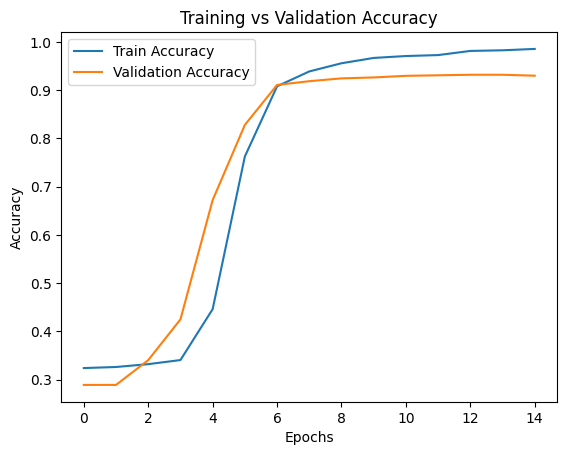

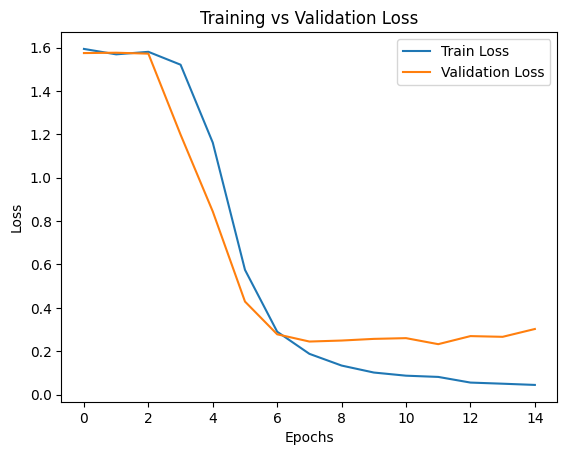

63/63 [==============================] - 2s 39ms/step


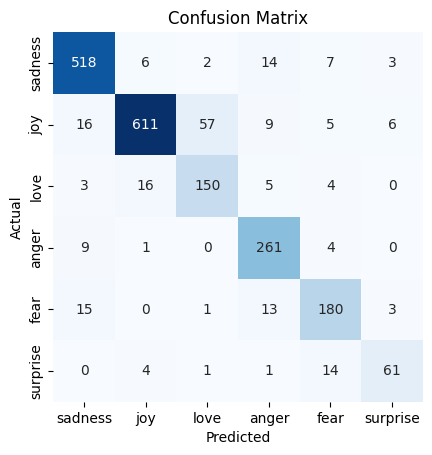

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})
Dataset({
    features: ['text', 'label'],
    num_rows: 14400
})
Dataset({
    features: ['text', 'label'],
    num_rows: 3600
})
Dataset({
    features: ['text', 'label'],
    num_rows: 2000
})
Training set shape: (14400, 35), (14400,)
Validation set shape: (3600, 35), (3600,)
Epoch 1/20
450/450 [==============================] - 87s 183ms/step - loss: 1.5907 - accuracy: 0.3260 - val_loss: 1.5745 - val_accuracy: 0.3406
Epoch 2/20
450/450 [==============================] - 75s 166ms/step - loss: 1.3986 - accuracy: 0.3756 - val_loss: 1.1840 - val_accuracy: 0.4514
Epoch 3/20
450/450 [==============================] - 79s 176ms/step - loss: 1.0225 - accuracy: 0.5131 - val_loss: 0.8662 - val_accuracy: 0.6086

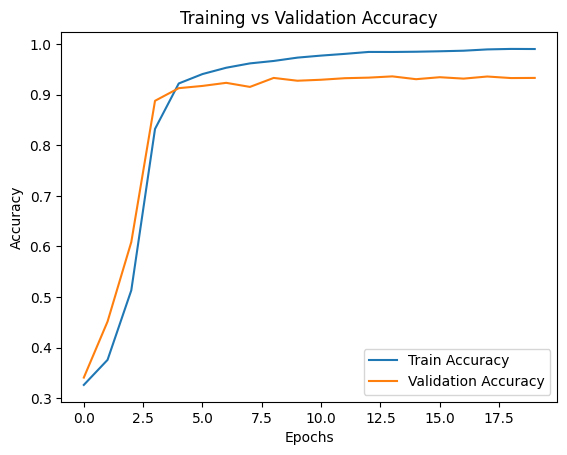

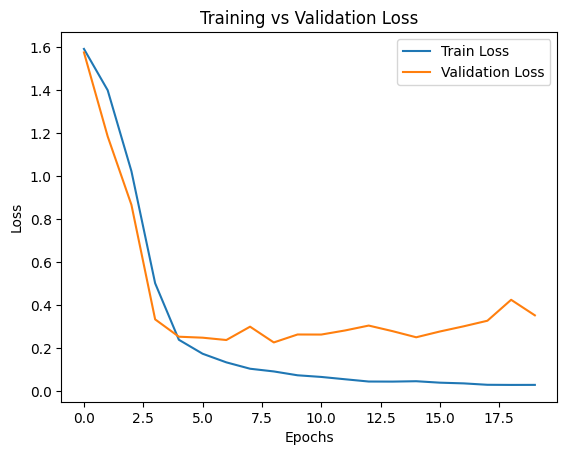

63/63 [==============================] - 3s 50ms/step


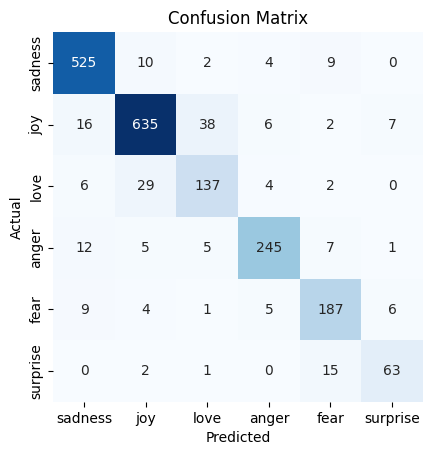

In [ ]:
def run_different_setups(setups):

  for n_epochs, _ in setups:
    train,val, test = load_data(shuffle=True, split_r = _)
    train,val,test = preprocess(train,val,test)
    tokenizer = get_tokenizer(train,val,test)
    train_X, train_y_one_hot, val_X, val_y_one_hot, max_seq_length = preprocess_data_(train,val,test)
    model = LSTMModel(6, max_seq_length)
    history = model.fit(train_X, train_y_one_hot, val_X,val_y_one_hot,n_epochs)
    plot_history_acc(history)
    plot_history_loss(history)
    test_X, test_y_one_hot, test_y = preprocess_test_data(test)
    y_pred_classes = model.predict(test_X)
    print(summarize(concatenate_datasets([test,train]),train,test, y_pred_classes))

    plot_confusion_matrix(test_y, y_pred_classes)


run_different_setups([(10,0.15),(15,0.2),(20,0.2)])
